In [1]:
import mdtraj as md
from jax import random
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from pyscripts.training_functions import Maths

In [2]:
fname_prmtop = 'Simulation/ala_deca_peptide.prmtop'
fname_dcd = 'Simulation/decaalanine_1us_split5.dcd'
math = Maths(fname_prmtop)

In [3]:
c = md.load(fname_dcd, top=fname_prmtop)
c = c.superpose(c)
coords = jnp.array(c.xyz)
coords = coords.reshape(coords.shape[0], -1)
print(coords.shape)

(10000, 306)


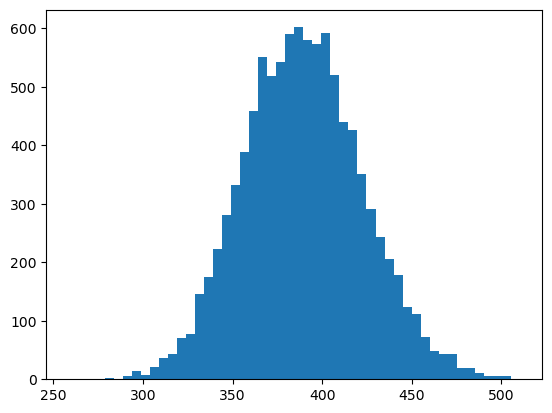

In [4]:
energies = math.ener_fun(coords)
_ = plt.hist(energies, bins=50)

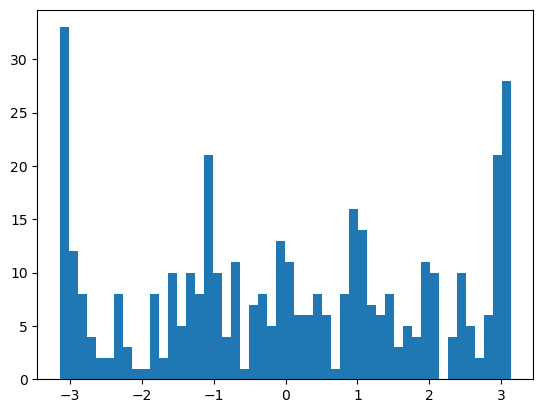

In [5]:
torsions = math.tors_fun(coords)
_ = plt.hist(torsions[69], bins=50)

In [17]:
a, b = coords[20:30], coords[30:40]
print(a.shape, b.shape)

(10, 306) (10, 306)


In [18]:
matrix = math.rmsd_distance_matrix(a, a)

In [19]:
bandwidth = jnp.min(matrix[jnp.where(matrix != 0)])

In [20]:
kernel = lambda x : jnp.exp(-1*(x**2)/bandwidth)

In [30]:
triu = jnp.triu(kernel(matrix), k=1)
print(triu)

[[0.         0.7758945  0.7852338  0.84899944 0.878749   0.7700151
  0.8730198  0.83215404 0.86808884 0.87116784]
 [0.         0.         0.8797854  0.87285274 0.77268803 0.8832443
  0.82733274 0.8334184  0.7971236  0.76475704]
 [0.         0.         0.         0.85749143 0.8122252  0.87197423
  0.8278059  0.8764531  0.7893729  0.7520237 ]
 [0.         0.         0.         0.         0.86731744 0.8784693
  0.8508548  0.8744879  0.8751165  0.78110325]
 [0.         0.         0.         0.         0.         0.837012
  0.877534   0.83375007 0.89262146 0.83936065]
 [0.         0.         0.         0.         0.         0.
  0.8317328  0.86687845 0.8418625  0.79145414]
 [0.         0.         0.         0.         0.         0.
  0.         0.8554155  0.91854995 0.8460319 ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.8490512  0.7961201 ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.8393509 ]
 [

In [27]:
triu_vals = triu[jnp.where(triu != 0)]

In [29]:
triu_vals.mean()

Array(0.83924323, dtype=float32)

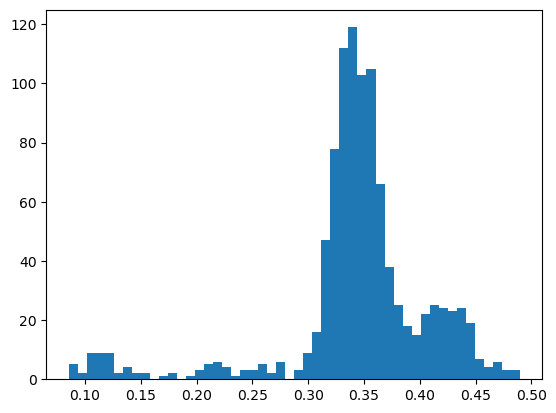

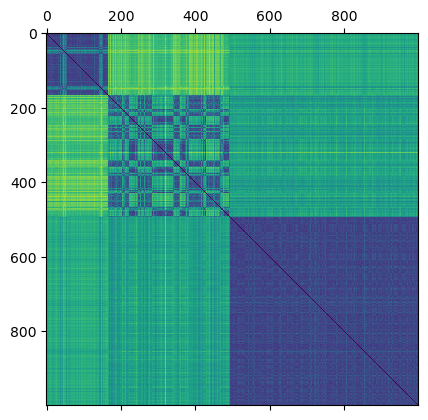

In [7]:
test1 = math.atom_rmsd(a, b)
test2 = math.rmsd_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)

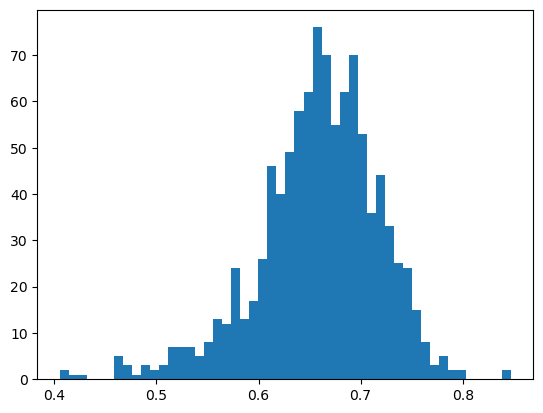

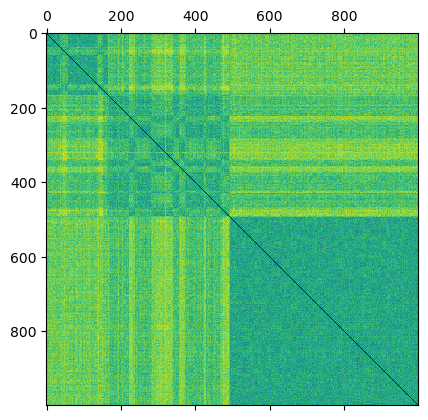

In [8]:
test1 = math.atom_rmtd(a, b)
test2 = math.rmtd_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)

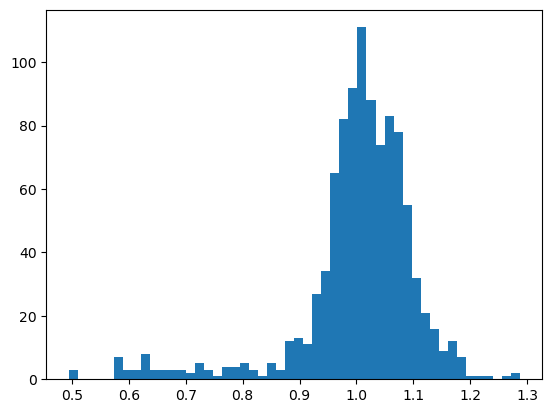

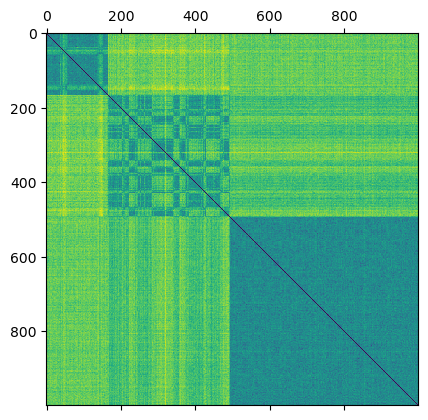

In [9]:
test1 = math.structural_distance(a, b)
test2 = math.structural_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)

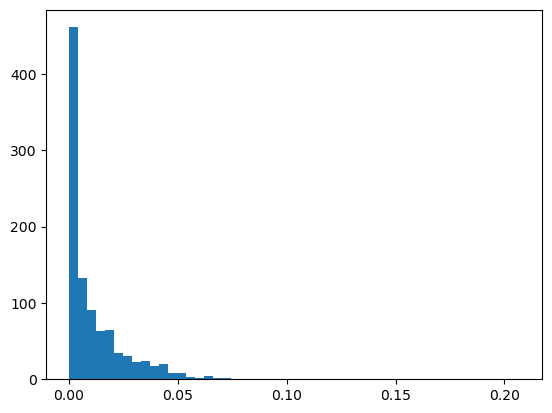

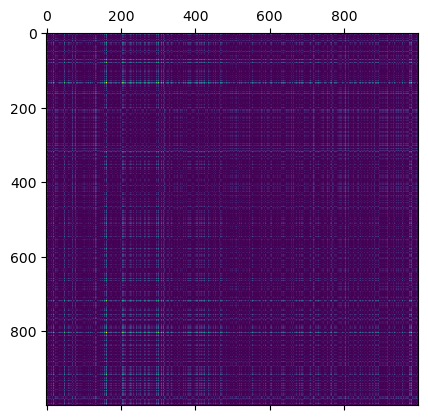

In [10]:
test1 = math.scaled_pot_enr_diff(a, b)
test2 = math.potential_distance_matrix(a, a)
_ = plt.hist(test1, bins=50)
plt.show()
_ = mpl.pyplot.matshow(test2)